<a href="https://colab.research.google.com/github/Huxwell/ColabNNs/blob/main/coco_explore.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch

In [ ]:
torch.__version__

'2.5.1+cu124'

In [1]:
!wget http://images.cocodataset.org/zips/train2017.zip

--2025-02-12 11:04:41--  http://images.cocodataset.org/zips/train2017.zip
Resolving images.cocodataset.org (images.cocodataset.org)... 52.217.167.129, 54.231.131.65, 16.15.176.214, ...
Connecting to images.cocodataset.org (images.cocodataset.org)|52.217.167.129|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 19336861798 (18G) [application/zip]
Saving to: ‘train2017.zip’

train2017.zip       100%[===================>]  18.01G  62.0MB/s    in 4m 45s  

2025-02-12 11:09:26 (64.8 MB/s) - ‘train2017.zip’ saved [19336861798/19336861798]



In [3]:
# 1. Download annotations (if not already downloaded)
!wget http://images.cocodataset.org/annotations/annotations_trainval2017.zip
!unzip -q annotations_trainval2017.zip

--2025-02-12 11:26:27--  http://images.cocodataset.org/annotations/annotations_trainval2017.zip
Resolving images.cocodataset.org (images.cocodataset.org)... 52.216.220.9, 16.15.192.104, 52.216.49.161, ...
Connecting to images.cocodataset.org (images.cocodataset.org)|52.216.220.9|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 252907541 (241M) [application/zip]
Saving to: ‘annotations_trainval2017.zip’

annotations_trainva 100%[===================>] 241.19M  30.0MB/s    in 4.7s    

2025-02-12 11:26:32 (51.8 MB/s) - ‘annotations_trainval2017.zip’ saved [252907541/252907541]



In [4]:
# 1. Unzip the dataset
!unzip -q /content/train2017.zip

# 2. Install necessary libraries
!pip install pycocotools==2.0.6
!pip install matplotlib

replace train2017/000000147328.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: N
n
loading annotations into memory...


KeyboardInterrupt: 

In [5]:
# 3. Import libraries
from pycocotools.coco import COCO
import matplotlib.pyplot as plt
import os

# 4. Load COCO annotations
dataDir='/content'
dataType='train2017'
annFile='{}/annotations/instances_{}.json'.format(dataDir,dataType)
coco=COCO(annFile)



loading annotations into memory...
Done (t=23.30s)
creating index...
index created!


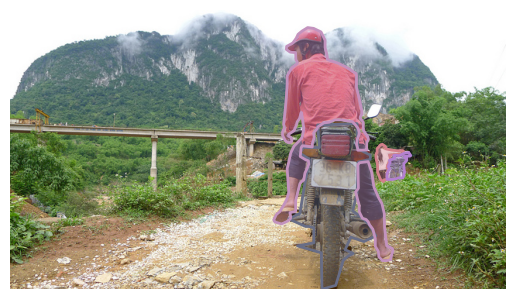

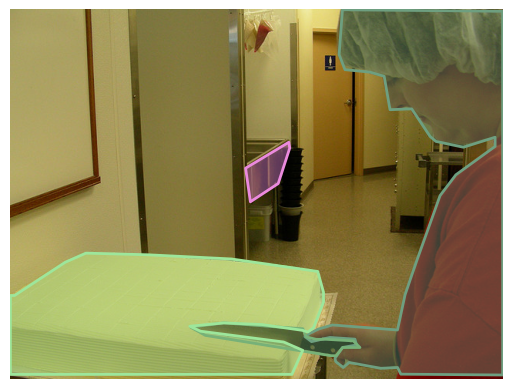

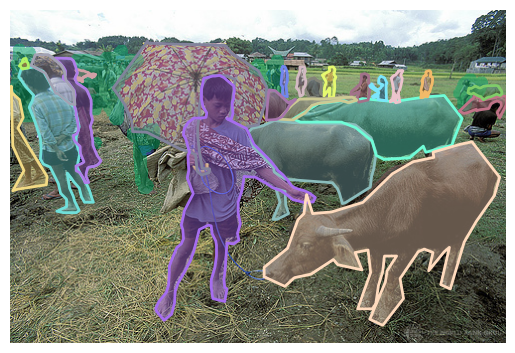

Total images before filtering: 118287
Total images after filtering (single object): 13893
creating index...
index created!


In [10]:
# 5. Display a few images (example: 3 images)
# Get image IDs
imgIds = coco.getImgIds()[:3]  # Limit visualization to 3 images
for imgId in imgIds:
    img = coco.loadImgs(imgId)[0]
    I = plt.imread(os.path.join(dataDir, dataType, img['file_name']))
    plt.axis('off')
    plt.imshow(I)

    # Get annotations for this image
    annIds = coco.getAnnIds(imgIds=img['id'])
    anns = coco.loadAnns(annIds)

    # Display annotations (bounding boxes and labels)
    coco.showAnns(anns)

    plt.show()

# 6. Filter for images with only 1 object
# Get ALL image IDs for filtering (not just the 3 visualized)
imgIds_all = coco.getImgIds()
imgIds_single_obj = [imgId for imgId in imgIds_all
                     if len(coco.getAnnIds(imgIds=imgId)) == 1]

# 7. Dataset stats before and after filtering
print(f"Total images before filtering: {len(imgIds_all)}")
print(f"Total images after filtering (single object): {len(imgIds_single_obj)}")
# 8. Create a new COCO object with filtered data (optional)
# This creates a new COCO object with only images containing a single object.
# Use this for any further analysis on this subset.
coco_filtered = COCO()
coco_filtered.dataset = coco.dataset
coco_filtered.dataset['images'] = coco.loadImgs(imgIds_single_obj)
coco_filtered.dataset['annotations'] = coco.loadAnns(coco.getAnnIds(imgIds=imgIds_single_obj))
coco_filtered.createIndex()

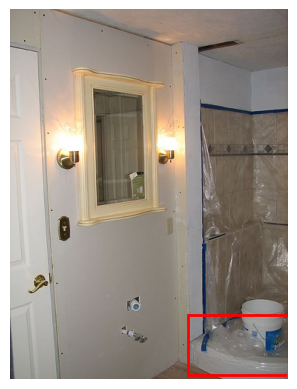

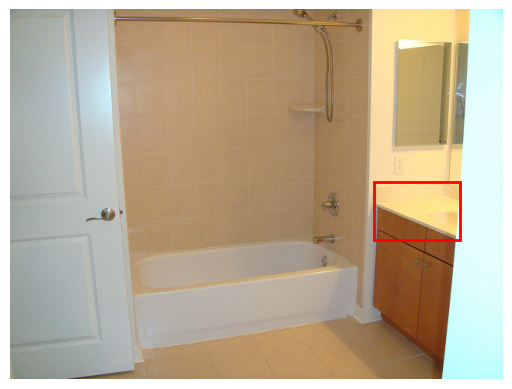

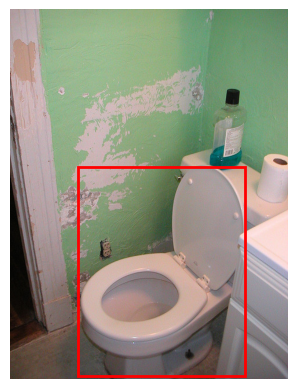

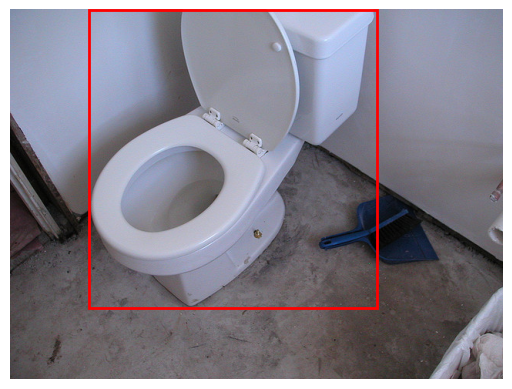

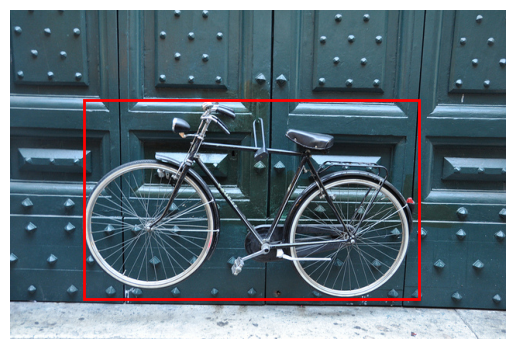

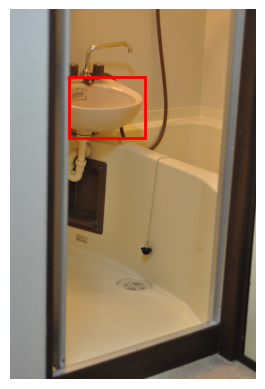

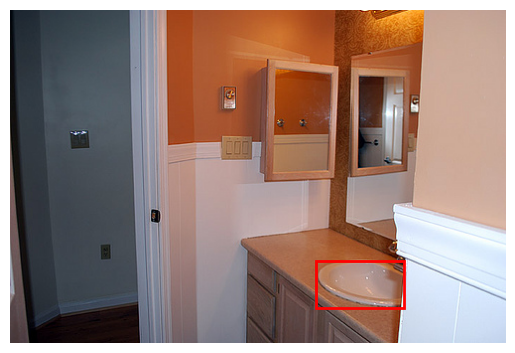

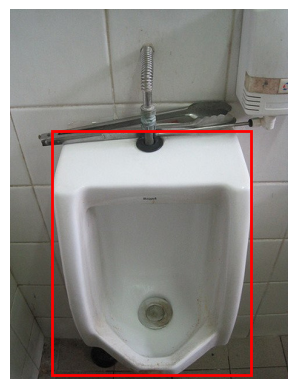

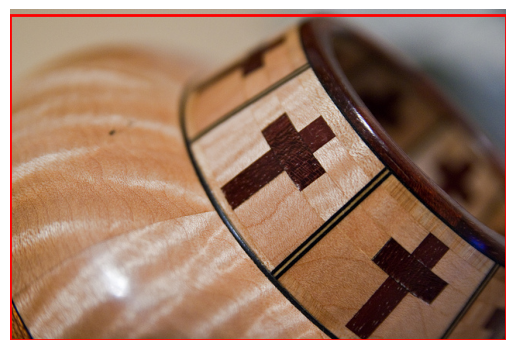

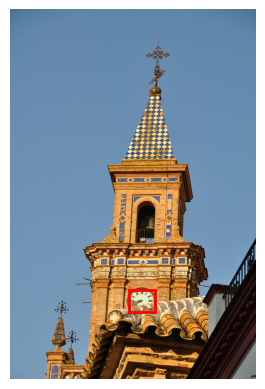

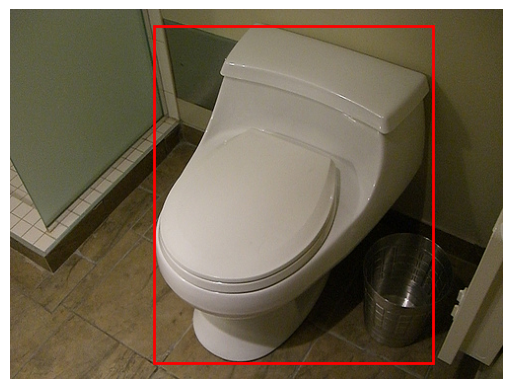

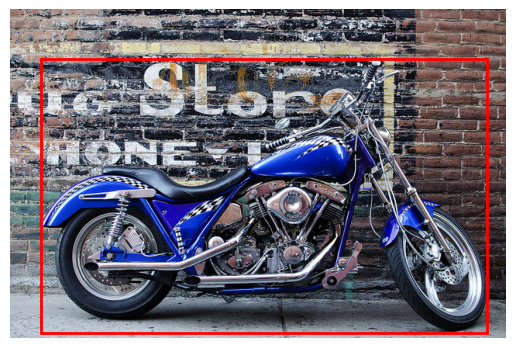

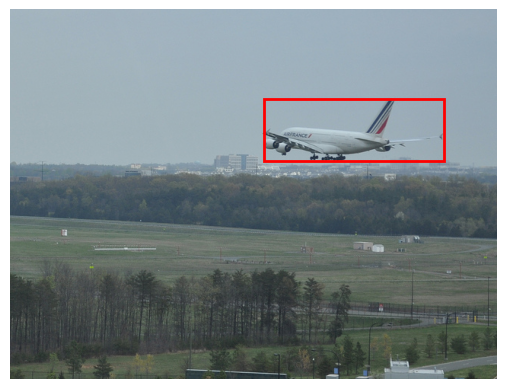

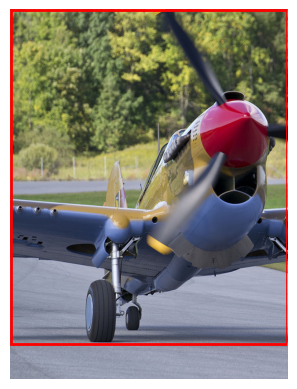

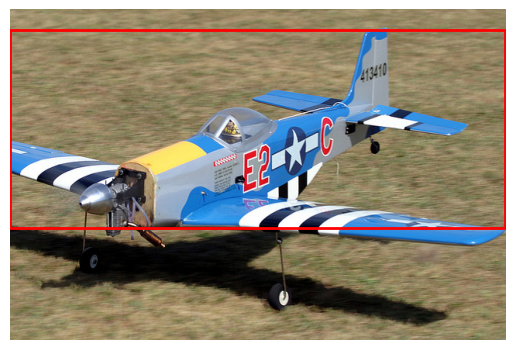

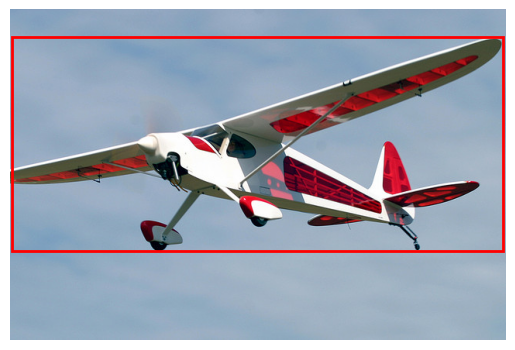

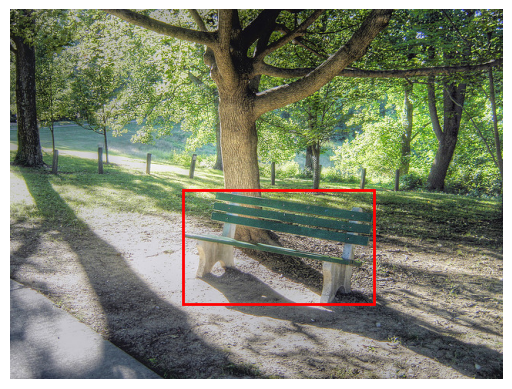

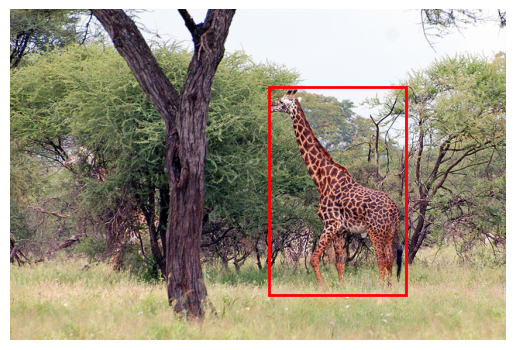

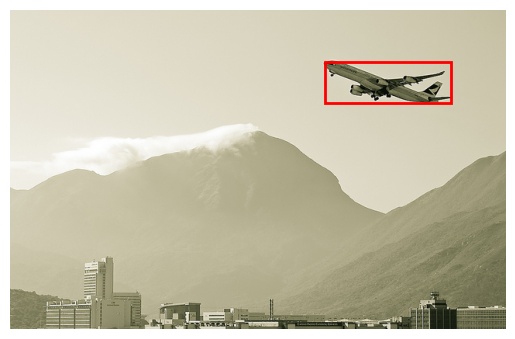

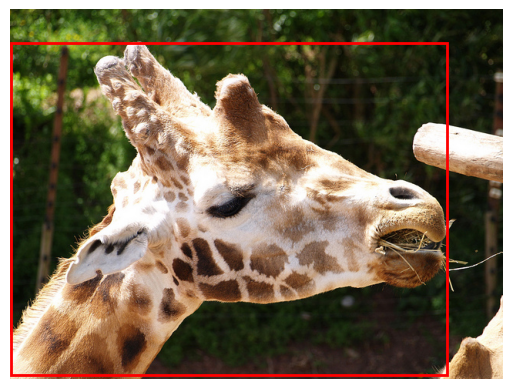

In [13]:
imgIds_filtered = coco_filtered.getImgIds()[:20]
for imgId in imgIds_filtered:
    img = coco_filtered.loadImgs(imgId)[0]
    I = plt.imread(os.path.join(dataDir, dataType, img['file_name']))
    plt.axis('off')
    plt.imshow(I)

    # Get bounding box annotations for this image
    annIds = coco_filtered.getAnnIds(imgIds=img['id'])
    anns = coco_filtered.loadAnns(annIds)

    # Display bounding boxes
    for ann in anns:
        bbox = ann['bbox']  # Get bounding box coordinates
        # Draw rectangle (adjust color and linewidth as needed)
        plt.gca().add_patch(plt.Rectangle((bbox[0], bbox[1]), bbox[2], bbox[3],
                                          linewidth=2, edgecolor='r', facecolor='none'))

    plt.show()

In [18]:
import json
import shutil
import os

# ... (previous code) ...

# 0. Download and unzip validation images (if not already downloaded)
!wget http://images.cocodataset.org/zips/val2017.zip
!unzip -q val2017.zip

# 1. Change dataType to 'val2017'
dataType = 'val2017'
# ... (rest of the code) ...

--2025-02-12 12:33:43--  http://images.cocodataset.org/zips/val2017.zip
Resolving images.cocodataset.org (images.cocodataset.org)... 52.216.153.116, 52.217.227.41, 54.231.226.153, ...
Connecting to images.cocodataset.org (images.cocodataset.org)|52.216.153.116|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 815585330 (778M) [application/zip]
Saving to: ‘val2017.zip’

val2017.zip         100%[===================>] 777.80M  70.4MB/s    in 23s     

2025-02-12 12:34:06 (34.3 MB/s) - ‘val2017.zip’ saved [815585330/815585330]



In [20]:
import json
import shutil
import os

# ... (previous code: unzipping, installations, imports, loading COCO) ...

# 1. Change dataType to 'val2017'
dataType = 'val2017'
annFile = '{}/annotations/instances_{}.json'.format(dataDir, dataType)
coco = COCO(annFile)

# 2. Filter for images with only 1 object
imgIds_all = coco.getImgIds()
imgIds_single_obj = [imgId for imgId in imgIds_all if len(coco.getAnnIds(imgIds=imgId)) == 1]

# 3. Dataset stats before and after filtering
print(f"Total images before filtering: {len(imgIds_all)}")
print(f"Total images after filtering (single object): {len(imgIds_single_obj)}")

# 4. Create a new COCO object with filtered data
coco_filtered = COCO()
coco_filtered.dataset = coco.dataset
coco_filtered.dataset['images'] = coco.loadImgs(imgIds_single_obj)
coco_filtered.dataset['annotations'] = coco.loadAnns(coco.getAnnIds(imgIds=imgIds_single_obj))
coco_filtered.createIndex()

# 5. Create output directory
output_dir = '/content/filtered_val2017'
os.makedirs(output_dir, exist_ok=True)
os.makedirs(os.path.join(output_dir, 'images'), exist_ok=True)
output_json_path = os.path.join(output_dir, 'instances_filtered_val2017.json')

# 6. Save filtered images and JSON
for img_info in coco_filtered.dataset['images']:
  # Copy image
  source_img_path = os.path.join(dataDir, dataType, img_info['file_name'])
  dest_img_path = os.path.join(output_dir, 'images', img_info['file_name'])
  shutil.copy(source_img_path, dest_img_path)

# Save JSON
with open(output_json_path, 'w') as f:
  json.dump(coco_filtered.dataset, f, indent=4)  # Added indent=4

print(f"Filtered images and JSON saved to: {output_dir}")

loading annotations into memory...
Done (t=0.54s)
creating index...
index created!
Total images before filtering: 5000
Total images after filtering (single object): 593
creating index...
index created!
Filtered images and JSON saved to: /content/filtered_val2017


In [17]:
!ls /content

annotations  annotations_trainval2017.zip  filtered_val2017  sample_data  train2017  train2017.zip


In [21]:
import json
import shutil
import os

# ... (previous code: unzipping, installations, imports, loading COCO, filtering) ...

# 1. Re-index annotations and images
new_img_id = 1
new_ann_id = 1
id_map = {}  # Mapping from old to new IDs

for img_info in coco_filtered.dataset['images']:
    id_map[img_info['id']] = new_img_id
    img_info['id'] = new_img_id
    new_img_id += 1

for ann_info in coco_filtered.dataset['annotations']:
    ann_info['id'] = new_ann_id
    ann_info['image_id'] = id_map[ann_info['image_id']]
    new_ann_id += 1

# 2. Save re-indexed JSON
output_json_path_reindexed = os.path.join(output_dir, 'instances_filtered_1_obj_reindexed_val2017.json')
with open(output_json_path_reindexed, 'w') as f:
  json.dump(coco_filtered.dataset, f, indent=4)

print(f"Re-indexed JSON saved to: {output_json_path_reindexed}")

Re-indexed JSON saved to: /content/filtered_val2017/instances_filtered_1_obj_reindexed_val2017.json


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [22]:
# ... (previous code: unzipping, installations, imports, loading COCO, filtering, re-indexing) ...

# 1. Zip the directory
!zip -r /content/filtered_val2017.zip /content/filtered_val2017

# 2. Download the zipped file
from google.colab import files
files.download('/content/filtered_val2017.zip')

  adding: content/filtered_val2017/ (stored 0%)
  adding: content/filtered_val2017/instances_filtered_val2017.json (deflated 88%)
  adding: content/filtered_val2017/instances_filtered_1_obj_reindexed_val2017.json (deflated 88%)
  adding: content/filtered_val2017/images/ (stored 0%)
  adding: content/filtered_val2017/images/000000482477.jpg (deflated 1%)
  adding: content/filtered_val2017/images/000000180188.jpg (deflated 1%)
  adding: content/filtered_val2017/images/000000290619.jpg (deflated 0%)
  adding: content/filtered_val2017/images/000000241297.jpg (deflated 0%)
  adding: content/filtered_val2017/images/000000005503.jpg (deflated 1%)
  adding: content/filtered_val2017/images/000000364587.jpg (deflated 1%)
  adding: content/filtered_val2017/images/000000031050.jpg (deflated 3%)
  adding: content/filtered_val2017/images/000000027932.jpg (deflated 1%)
  adding: content/filtered_val2017/images/000000109827.jpg (deflated 5%)
  adding: content/filtered_val2017/images/000000309452.jpg (

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>